# Delivery Performance Analysis — Olist E-Commerce

Analyzing delivery times and on-time performance using the cleaned `analysis_df` built in 
`01_data_cleaning.ipynb`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

analysis_df = pd.read_csv('../data/analysis_df.csv')

date_cols = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_carrier_date', 'order_delivered_customer_date', 
             'order_estimated_delivery_date', 'shipping_limit_date']
for col in date_cols:
    analysis_df[col] = pd.to_datetime(analysis_df[col])

print(analysis_df.shape)

(112650, 34)


## 2. On-Time vs. Late Delivery

**Question:** What % of orders arrive by the estimated delivery date, and how long does delivery typically take?

**Note:** 8 orders marked `delivered` have no delivery date, and 6 orders marked `canceled` do 
have one (likely delivered-then-returned/canceled) — both are source data inconsistencies, 
affecting <0.01% of orders. This analysis uses delivery date presence as the source of truth, 
not status label.

In [2]:
order_delivery = analysis_df.drop_duplicates(subset='order_id')[
    ['order_id', 'order_status', 'order_delivered_customer_date', 
     'order_estimated_delivery_date', 'order_purchase_timestamp']
].copy()

# Use presence of delivery date, not status label
delivered = order_delivery.dropna(subset=['order_delivered_customer_date']).copy()
delivered['delivery_days'] = (delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']).dt.days
delivered['delay_days'] = (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']).dt.days
delivered['on_time'] = delivered['delay_days'] <= 0

print("Orders analyzed:", len(delivered))
print("Avg delivery time:", round(delivered['delivery_days'].mean(), 1), "days")
print("Median delivery time:", delivered['delivery_days'].median(), "days")
print()
print("% on-time:", round(delivered['on_time'].mean() * 100, 1), "%")
print("Avg delay among late orders:", round(delivered[delivered['delay_days'] > 0]['delay_days'].mean(), 1), "days")

Orders analyzed: 96476
Avg delivery time: 12.1 days
Median delivery time: 10.0 days

% on-time: 93.2 %
Avg delay among late orders: 10.6 days


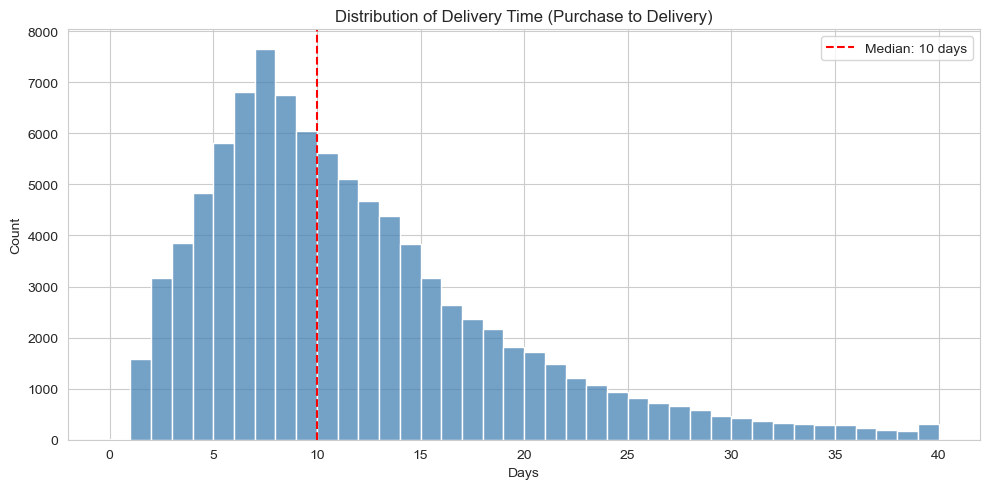

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(delivered[delivered['delivery_days'] <= 40]['delivery_days'], bins=40, color='steelblue')
plt.axvline(delivered['delivery_days'].median(), color='red', linestyle='--', label=f"Median: {delivered['delivery_days'].median():.0f} days")
plt.title('Distribution of Delivery Time (Purchase to Delivery)')
plt.xlabel('Days')
plt.legend()
plt.tight_layout()
plt.savefig('../images/delivery_time_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Delivery averages 12.1 days (median 10 days) from purchase to arrival. The platform 
performs well against its own estimates — 93.2% of orders arrive on or before the estimated 
delivery date, with late orders averaging 10.6 days beyond the estimate when they do slip.

## 3. Delivery Time by State

**Question:** Does delivery speed and reliability vary geographically?

**Note:** States with fewer than 30 delivered orders are excluded to avoid small-sample noise.

In [4]:
order_delivery = analysis_df.drop_duplicates(subset='order_id')[
    ['order_id', 'customer_state', 'order_delivered_customer_date', 
     'order_purchase_timestamp', 'order_estimated_delivery_date']
].copy()

delivered = order_delivery.dropna(subset=['order_delivered_customer_date']).copy()
delivered['delivery_days'] = (delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']).dt.days
delivered['delay_days'] = (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']).dt.days
delivered['on_time'] = delivered['delay_days'] <= 0

state_delivery = delivered.groupby('customer_state').agg(
    avg_delivery_days=('delivery_days', 'mean'),
    order_count=('order_id', 'count'),
    pct_on_time=('on_time', 'mean')
).reset_index()

state_delivery['pct_on_time'] = (state_delivery['pct_on_time'] * 100).round(1)
state_delivery = state_delivery[state_delivery['order_count'] >= 30].sort_values('avg_delivery_days', ascending=False)

state_delivery.round(1)

,customer_state,avg_delivery_days,order_count,pct_on_time
21,RR,29.0,41,87.8
3,AP,26.7,67,97.0
2,AM,26.0,145,97.2
1,AL,24.0,397,78.6
13,PA,23.3,946,88.8
9,MA,21.1,717,82.6
24,SE,21.0,335,84.8
5,CE,20.8,1279,86.2
0,AC,20.6,80,96.2
14,PB,20.0,517,89.6


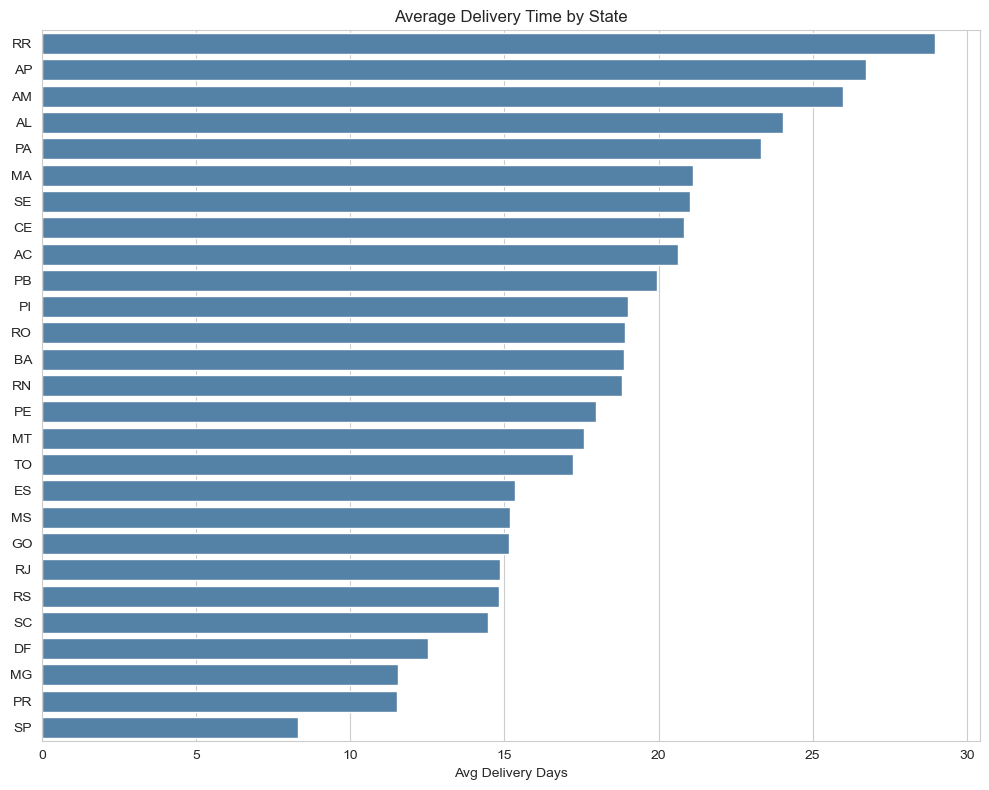

In [5]:
plt.figure(figsize=(10, 8))
sns.barplot(data=state_delivery, x='avg_delivery_days', y='customer_state', color='steelblue')
plt.title('Average Delivery Time by State')
plt.xlabel('Avg Delivery Days')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../images/delivery_time_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** SP delivers fastest (8.3 days avg, 95.5% on-time), consistent with it being Olist's 
commercial hub. The slowest states are in Brazil's remote North region (RR at 29 days, AP at 26.7, 
AM at 26.0) — expected given distance and infrastructure. On-time rate doesn't always track speed: 
AM is slow but highly reliable (97.2% on-time), while AL is both slow and less reliable (78.6%), 
suggesting AL specifically may be a genuine logistics weak point.

## 4. Delivery Delay vs. Review Score

**Question:** Does a late delivery hurt customer satisfaction? And does this explain the low 
furniture ratings seen in `03_eda_product_customer.ipynb`?

In [6]:
order_level = analysis_df.drop_duplicates(subset='order_id')[
    ['order_id', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'review_score']
].copy()

delivered = order_level.dropna(subset=['order_delivered_customer_date']).copy()
delivered['delay_days'] = (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']).dt.days
delivered['on_time'] = delivered['delay_days'] <= 0
delivered['delivery_bucket'] = delivered['on_time'].map({True: 'on-time', False: 'late'})

review_by_delivery = delivered.groupby('delivery_bucket')['review_score'].agg(['mean', 'count']).reset_index()
review_by_delivery

,delivery_bucket,mean,count
0,late,2.270918,6382
1,on-time,4.290135,89448


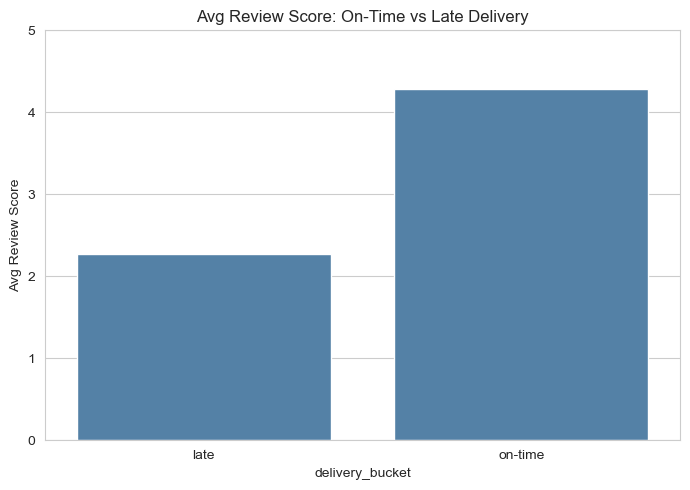

In [7]:
plt.figure(figsize=(7, 5))
sns.barplot(data=review_by_delivery, x='delivery_bucket', y='mean', color='steelblue')
plt.title('Avg Review Score: On-Time vs Late Delivery')
plt.ylabel('Avg Review Score')
plt.ylim(0, 5)
plt.tight_layout()
plt.savefig('../images/review_vs_delivery.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Check whether office_furniture specifically has worse on-time performance
furniture_order_ids = analysis_df[analysis_df['product_category_name_english'] == 'office_furniture']['order_id'].unique()
furniture_delivery = delivered[delivered['order_id'].isin(furniture_order_ids)]

print("office_furniture % on-time:", round(furniture_delivery['on_time'].mean() * 100, 1), "%")
print("Overall % on-time:", round(delivered['on_time'].mean() * 100, 1), "%")

office_furniture % on-time: 91.9 %
Overall % on-time: 93.2 %


**Insight:** Late delivery has a severe impact on satisfaction — on-time orders average 4.29, 
late orders average just 2.27, and longer delays correlate with lower scores (r = -0.147 among 
late orders). However, `office_furniture`'s on-time rate (91.9%) is close to the overall average 
(93.2%), meaning delivery delay does **not** explain its low review score from the previous 
notebook — the cause is more likely product-related (e.g. assembly difficulty, damage in transit) 
rather than shipping performance.

## Summary — Key Delivery Insights

1. **Delivery is generally reliable:** Average delivery time is 12.1 days (median 10 days), and 
   93.2% of orders arrive on or before the estimated delivery date. Late orders slip by an 
   average of 10.6 days beyond the estimate.

2. **Delivery speed and reliability vary sharply by geography:** SP delivers fastest (8.3 days, 
   95.5% on-time), reflecting its role as Olist's commercial hub. Brazil's remote North region 
   (RR, AP, AM) is slowest (26-29 days), consistent with distance and infrastructure — though 
   some slow states (AM) remain highly reliable (97.2% on-time) due to realistic estimates, while 
   others (AL) are both slow and unreliable (78.6% on-time), marking it a genuine logistics weak spot.

3. **Late delivery severely damages satisfaction:** Review scores drop from 4.29 (on-time) to 
   2.27 (late) — the strongest relationship found across both EDA notebooks. Longer delays 
   correlate with progressively lower scores. However, this does **not** explain furniture's low 
   ratings from `03_eda_product_customer.ipynb` — `office_furniture`'s on-time rate (91.9%) is 
   close to average, pointing instead to product-related causes (assembly, damage) rather than 
   shipping performance.

**Next steps:** These findings feed into the final `05_key_insights.ipynb`, consolidating the 
strongest, most actionable patterns across sales, product, customer, and delivery analysis.